In [84]:
import numpy as np

In [85]:
np.random.seed(37)
n = 78
data = np.random.randn(n,2) + np.random.random((n, 2)) * np.e
h = 0.5
c = np.array([
    [1.5, 1.5],
    [0.0, 0.0],
    [-1.0, 2.0]
])

In [86]:
# (78, 2) c
# (3, 2) c

In [87]:
def rbf(X, h, c):
    diff = X[:, np.newaxis, :] - c[np.newaxis, :, :]
    dist = np.linalg.norm(diff, axis=-1)
    return np.exp(-dist**2/(2*h**2))
rbf(data, h, c)

array([[2.57796304e-05, 6.20585903e-10, 5.40197483e-03],
       [7.00637505e-07, 3.03495650e-07, 2.61183996e-19],
       [3.27748475e-01, 1.26804566e-07, 2.20365242e-07],
       [4.08591461e-04, 1.15691449e-04, 5.61498412e-14],
       [8.76889813e-08, 1.45315870e-11, 7.57236877e-24],
       [8.81320275e-01, 9.16288869e-04, 8.92392047e-06],
       [3.44634026e-01, 2.14954306e-03, 8.83532239e-08],
       [6.77852521e-01, 2.62665982e-05, 2.01796553e-08],
       [1.02898582e-08, 8.51141052e-24, 1.23150198e-21],
       [9.87537402e-02, 4.56597797e-07, 1.25073984e-04],
       [1.80040378e-04, 9.45861101e-02, 1.61382663e-09],
       [3.00861806e-06, 4.43739353e-06, 1.59208359e-17],
       [1.48886602e-03, 4.88746789e-10, 8.70400259e-05],
       [4.45956130e-06, 3.65065941e-07, 1.52892244e-18],
       [3.87672174e-02, 3.40904147e-06, 3.46698691e-03],
       [6.15618421e-01, 2.81307569e-06, 1.18417272e-08],
       [1.39013085e-09, 2.40253658e-04, 1.55110530e-16],
       [4.60089656e-01, 3.18945

In [88]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X, y = make_blobs()
print(X.shape)
print(y.shape)

(100, 2)
(100,)


In [89]:
kmeans = KMeans(8).fit(X)

c:\Users\PC\anaconda3\envs\ds_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


(168, 134)


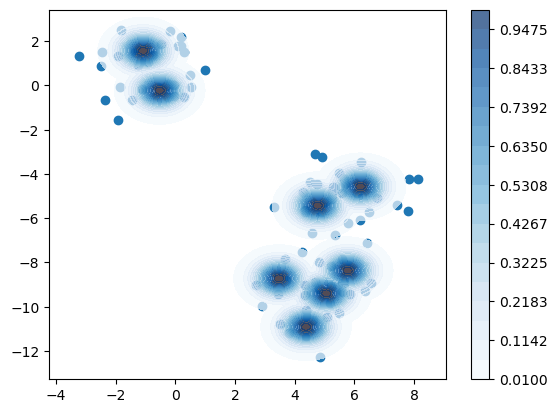

In [90]:
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1])
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='x', s=100, lw=5)

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
print(xx.shape)
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = rbf(grid_points, h, kmeans.cluster_centers_).max(axis=1).reshape(xx.shape)
levels = np.linspace(0.01, Z.max(), 20) 
contour = plt.contourf(xx, yy, Z, levels=levels, cmap='Blues', alpha=0.7)
plt.colorbar(contour)